# 03 — Avaliação do holdout e validação externa

**Dataset usado na avaliação: `Fakerecogna_extrativo.csv`.**

O modelo avaliado é o ensemble stacking congelado do notebook 02. Por ser um corpus extrativo derivado do FakeRecogna, esta avaliação mede robustez; sua independência externa não está certificada.

Carrega exclusivamente o bundle do notebook 02. Não treina, não altera o vocabulário e não salva outro modelo. Após observar este teste, mudanças metodológicas exigem um novo teste independente. Resultados antigos foram removidos por não corresponderem a este protocolo.

## Carregamento do modelo e conferência das partições

A célula abaixo importa as bibliotecas e funções compartilhadas, localiza a raiz do projeto e carrega o bundle do stacking salvo no 02. Confere o manifesto e os hashes das partições para garantir que o modelo, o treino e o holdout pertencem à mesma execução. Verifica textos vazios e sobreposição de textos, IDs e grupos de similaridade entre treino e holdout. Interrompe a execução se encontrar incompatibilidades. Não treina nenhum classificador.

In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
import pipeline_utils
importlib.reload(pipeline_utils)
from pipeline_utils import (project_root, compose_text, normalize_text, validate_labels,
                            sha256_file, load_bundle, LABEL_NAMES, SCHEMA_VERSION, MODEL_RELATIVE,
                            INPUT_POLICY, FEATURE_COLUMNS, checking_signals,
                            TRAIN_COLUMNS, PROCESSED_COLUMNS, EXTERNAL_COLUMNS,
                            validate_schema, make_features, prepare_authors,
                            load_manifest, read_partition, fitted_base_features)
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
import json
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from urllib.parse import urlsplit, unquote
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import HashingVectorizer
from typing import cast
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from IPython.display import Markdown, display
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef, average_precision_score,
                             roc_curve, precision_recall_curve)
bundle = load_bundle(ROOT / MODEL_RELATIVE)
model = cast(Pipeline, bundle["pipeline"])
manifest = load_manifest(DATA_DIR)
if manifest != bundle["manifest"]:
    raise ValueError("Modelo e partições pertencem a execuções diferentes.")
for name, expected in manifest["files"].items():
    if sha256_file(DATA_DIR / name) != expected:
        raise ValueError(f"Partição alterada: {name}")
train = read_partition(DATA_DIR / "train.csv")
holdout = read_partition(DATA_DIR / "test_holdout.csv")
validate_schema(train, PROCESSED_COLUMNS, context="treino")
validate_schema(holdout, PROCESSED_COLUMNS, context="holdout")
if holdout.texto.isna().any() or holdout.texto.map(normalize_text).eq("").any():
    raise ValueError("Texto vazio no holdout.")
train_keys = set(train.texto.map(normalize_text))
if not train_keys.isdisjoint(holdout.texto.map(normalize_text)):
    raise ValueError("Sobreposição entre treino e holdout.")
if not set(train.id_original).isdisjoint(holdout.id_original):
    raise ValueError("IDs compartilhados entre treino e holdout.")
if "grupo_similaridade" in train and "grupo_similaridade" in holdout:
    if not set(train.grupo_similaridade).isdisjoint(holdout.grupo_similaridade):
        raise ValueError("Grupo de similaridade compartilhado entre as partições.")


## PLN e TF-IDF no pipeline — previsão e métricas do holdout

Define a função evaluate, reutilizada posteriormente no CSV extrativo. Ela valida as colunas e os rótulos, chama predict e decision_function do pipeline congelado e calcula acurácia, F1-macro, precisão, recall e F1 por classe, matriz de confusão e ROC-AUC quando há duas classes. O próprio pipeline aplica a normalização de texto, o TF-IDF e a codificação de autor já ajustados no treinamento.

Em seguida, avalia o holdout interno reservado no 01, exibe as métricas e salva os resultados, as previsões e os erros. A margem de decisão é um escore, não uma probabilidade calibrada. O holdout não constitui uma base externa.

**PLN (Processamento de Linguagem Natural):** ao chamar predict e decision_function, o pipeline combina título e notícia e aplica normalize_text, com normalização Unicode, decodificação de entidades HTML, conversão para minúsculas, padronização de URLs e tratamento de tags, pontuação e espaços. **TF-IDF:** cada base reutiliza o vetorizador ajustado no treino, com unigramas e bigramas, para transformar o texto antes da classificação. A autoria segue sua codificação separada. Nenhum novo vocabulário ou peso IDF é ajustado no holdout.

In [2]:
def evaluate(frame, name):
    validate_schema(frame, FEATURE_COLUMNS + ["texto", "label"], context=name)
    if frame.empty or frame["Noticia"].fillna("").astype(str).str.strip().eq("").any():
        raise ValueError("Base vazia ou Noticia não preenchida na avaliação.")
    if not compose_text(frame).map(normalize_text).eq(frame["texto"].map(normalize_text)).all():
        raise ValueError("Texto da avaliação diverge de Titulo + Noticia.")
    y = validate_labels(frame["label"])
    if frame["texto"].isna().any() or frame["texto"].map(normalize_text).eq("").any():
        raise ValueError("Entradas vazias na avaliação.")
    pred = model.predict(frame[FEATURE_COLUMNS])
    margins = model.decision_function(frame[FEATURE_COLUMNS])
    report = classification_report(y, pred, labels=[0, 1], target_names=["Fake", "Real"],
                                   output_dict=True, zero_division=0)
    if not isinstance(report, dict):
        raise TypeError("Relatório de classificação deve ser um dicionário.")
    print(name)
    display(pd.DataFrame(report).T)
    display(pd.DataFrame(confusion_matrix(y, pred, labels=[0, 1]),
                        index=["Realidade: Fake", "Realidade: Real"],
                        columns=["Predição: Fake", "Predição: Real"]))
    metrics = {"n": len(frame), "accuracy": float(accuracy_score(y, pred)),
               "f1_macro": float(f1_score(y, pred, labels=[0, 1], average="macro", zero_division=0)),
               "roc_auc_real": float(roc_auc_score(y, margins)) if y.nunique() == 2 else None,
               "classification_report": report,
               "confusion_matrix": confusion_matrix(y, pred, labels=[0, 1]).tolist()}
    audit = frame.copy()
    audit["predito"] = pred
    audit["margem_real"] = margins
    audit["acerto"] = y.to_numpy() == pred
    return metrics, audit

holdout_metrics, audit = evaluate(holdout, "Holdout reservado")
REPORT_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "holdout_metrics.json").write_text(json.dumps(
    {"schema_version": SCHEMA_VERSION, "label_names": LABEL_NAMES,
     "model_sha256": sha256_file(ROOT / MODEL_RELATIVE),
     "holdout_sha256": sha256_file(DATA_DIR / "test_holdout.csv"),
     "cv_f1_macro": bundle["cv_f1_macro"], "holdout": holdout_metrics},
    indent=2, ensure_ascii=False), encoding="utf-8")
audit.to_csv(REPORT_DIR / "predicoes_holdout.csv", index=False)
audit.loc[~audit["acerto"]].to_csv(REPORT_DIR / "erros_holdout.csv", index=False)
display(audit.loc[~audit["acerto"]].head(20))


Holdout reservado


,precision,recall,f1-score,support
Fake,0.995809,0.990826,0.993311,1199.000000
Real,0.990764,0.995781,0.993266,1185.000000
accuracy,0.993289,0.993289,0.993289,0.993289
macro avg,0.993286,0.993303,0.993289,2384.000000
weighted avg,0.993301,0.993289,0.993289,2384.000000


,Predição: Fake,Predição: Real
Realidade: Fake,1188,11
Realidade: Real,5,1180


,id_original,Titulo,Noticia,Autor,texto,label,grupo_similaridade,fonte_auditoria,data_auditoria,evento_auditoria,predito,margem_real,acerto
158,754,Blogueira relata ataques em rede social após v...,o influenciadora tininha mattos vidar virar ca...,Sara Baptista,Blogueira relata ataques em rede social após v...,1,754,noticias.uol.com.br,,,0,-2.732950,False
210,1048,Vídeos de YouTube com informações falsas somam...,vídeo mentira d postar haver ano e somar milhã...,"Por Deslange Paiva* e Thiago Lavado, G1",Vídeos de YouTube com informações falsas somam...,1,1048,g1.globo.com,,,0,-2.670745,False
368,1793,Cocaína não mata o coronavírus,haver o assunto s informação verdadeiro surgir...,Lucas Borges Teixeira,Cocaína não mata o coronavírus haver o assunto...,1,1793,noticias.uol.com.br,,,0,-9.715529,False
487,2416,Homem preso por atear fogo à mata no Amazonas ...,homem deter crime ambiental iranduba cidade vi...,30/08/2019 00h00,Homem preso por atear fogo à mata no Amazonas ...,0,2416,noticias.uol.com.br,,,1,1.000576,False
596,2969,É falso que cloroquina teria salvado 100 mil v...,o cloroquina salvar vidar perdido brasil duran...,Covid: É enganoso post que questiona ética dos...,É falso que cloroquina teria salvado 100 mil v...,0,2969,noticias.uol.com.br,,,1,0.843073,False
738,3635,"Ao criticar vacina chinesa, Bolsonaro mente e ...",o o desautorizar público o ministrar saudar ge...,"Do UOL, em São Paulo","Ao criticar vacina chinesa, Bolsonaro mente e ...",0,3635,noticias.uol.com.br,,,1,1.947079,False
1225,6017,Homem morre após pegar coronavírus de neto que...,homem ano morrer coronavírus infectar neto vol...,"Do UOL, em São Paulo",Homem morre após pegar coronavírus de neto que...,1,6017,noticias.uol.com.br,,,0,-0.330229,False
1324,6522,Uso de máscaras pode conter disseminação de do...,imagem comum surgimento surto e epidemiar o pe...,Por G1,Uso de máscaras pode conter disseminação de do...,1,6522,g1.globo.com,,,0,-0.411554,False
1454,7224,Nova lei eleitoral não valerá em 2020 se Bolso...,tuíte viralizou rede social sugerir o o presid...,19/09/2019 21h00,Nova lei eleitoral não valerá em 2020 se Bolso...,0,7224,noticias.uol.com.br,,,1,2.076549,False
1474,7311,Deputado mostra dados enganosos sobre mortes p...,postagem deputar federal daniel silveiro psl-r...,Covid: Estudo da USP analisa eficácia da colch...,Deputado mostra dados enganosos sobre mortes p...,0,7311,noticias.uol.com.br,,,1,3.431056,False


## FakeRecogna extrativo — PLN, rótulos e auditoria de origem

Lê o CSV original e valida Titulo, Noticia, Autor e Label. Usa explicitamente Label 1 = Fake e 0 = Real, invertendo para o contrato 0 = Fake e 1 = Real. O mapeamento é sustentado pelos exemplos de fontes de checagem e pelos rótulos das notícias correspondentes no corpus original; divergências são exportadas, não corrigidas por previsões. A autoria e o título podem identificar fontes e vereditos. PLN usa normalize_text para detectar duplicatas. Este corpus derivado não é automaticamente independente do FakeRecogna.

| Classe | Label original do CSV | label usada nas métricas |
|---|---:|---:|
| Fake | 1 | 0 |
| Real | 0 | 1 |

A conversão ocorre uma única vez, ao ler a coluna original Label. A coluna label convertida é usada nas métricas; predict já retorna o padrão do treinamento. O arquivo original não é sobrescrito.

In [3]:
EXTERNAL_PATH = ROOT / "data/fakerecogna_extrativo.csv"
EXTERNAL_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR = EXTERNAL_DIR / "graficos"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
# CSV original: 1 = Fake, 0 = Real. Modelo: 0 = Fake, 1 = Real.
LABEL_MAP = {1: 0, 0: 1}
raw = pd.read_csv(EXTERNAL_PATH, keep_default_na=False)
validate_schema(raw, FEATURE_COLUMNS + ["Label", "URL"], context="CSV extrativo")
external_all = raw.copy()
external_all["id_externo"] = np.arange(len(raw))
# Valida antes de converter; Label é preservada com o valor original.
rotulos_originais = validate_labels(raw["Label"])
external_all["label"] = validate_labels(rotulos_originais.map(LABEL_MAP))
external_all["texto"] = compose_text(external_all)
external_all["texto_normalizado"] = external_all.texto.map(normalize_text)
external_all["palavras"] = external_all.texto_normalizado.map(lambda text: len(str(text).split()))
external_all["pistas_editoriais"] = external_all.texto.map(lambda text: " | ".join(checking_signals(text)))
original = pd.read_excel(ROOT / "data/FakeRecogna.xlsx").fillna("")
validate_schema(original, TRAIN_COLUMNS + ["URL"], context="referência de origem")
def chave(value):
    return str(value).strip().casefold().rstrip("/")
urls = set(original.URL.map(chave)) - {""}
titulos = set(original.Titulo.map(normalize_text)) - {""}
textos = set(compose_text(original).map(normalize_text)) - {""}
external_all["sobreposicao_url"] = external_all.URL.map(chave).ne("") & external_all.URL.map(chave).isin(urls)
external_all["sobreposicao_titulo"] = external_all.Titulo.map(normalize_text).ne("") & external_all.Titulo.map(normalize_text).isin(titulos)
external_all["sobreposicao_texto"] = external_all.texto_normalizado.isin(textos)
external_all["vazio"] = external_all.Noticia.astype(str).str.strip().eq("") | external_all.texto_normalizado.eq("")
external_all["duplicata"] = external_all.texto_normalizado.duplicated()
conflitos = external_all.groupby("texto_normalizado").label.nunique()
external_all["conflito"] = external_all.texto_normalizado.isin(conflitos.loc[conflitos.gt(1)].index)
checagem_rotulos = external_all[["id_externo", "URL", "label"]].copy()
checagem_rotulos["url_chave"] = checagem_rotulos.URL.map(chave)
referencia_rotulos = original[["URL", "Classe"]].copy()
referencia_rotulos["url_chave"] = referencia_rotulos.URL.map(chave)
referencia_rotulos = referencia_rotulos.loc[referencia_rotulos.Classe.isin([0, 1]) & referencia_rotulos.url_chave.ne("")]
checagem_rotulos = checagem_rotulos.merge(referencia_rotulos, on="url_chave", how="inner")
checagem_rotulos["rotulo_divergente"] = checagem_rotulos.label.ne(checagem_rotulos.Classe)
checagem_rotulos.to_csv(EXTERNAL_DIR / "rotulos_correspondentes.csv", index=False)
print("Registros:", len(external_all))
display(external_all.label.value_counts().rename(index=LABEL_NAMES))


Registros: 52800


label
Fake    26400
Real    26400
Name: count, dtype: int64

## EDA e seleção antes das previsões

Exibe classes, comprimentos e sinais de checagem. Exporta ausências por classe e separa textos vazios, duplicatas, conflitos e coincidências de URL, título ou texto com a base original. As exclusões usam todo o FakeRecogna, incluindo treino e holdout. O restante ainda não tem independência por evento comprovada.

Após bloqueios iniciais: 46230


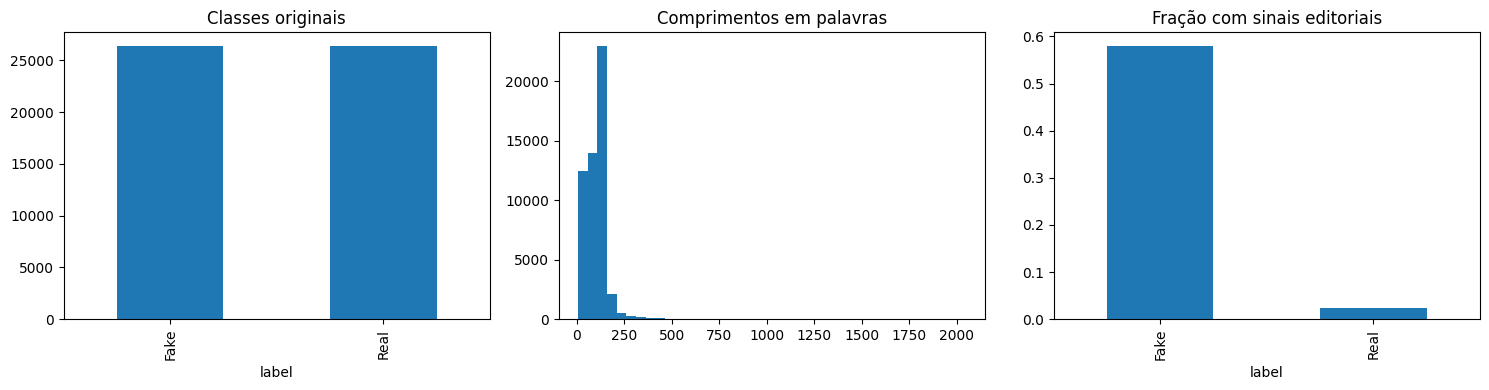

In [4]:
ausentes = []
for label in [0, 1]:
    grupo = external_all.loc[external_all.label.eq(label)]
    for coluna in FEATURE_COLUMNS:
        ausentes.append({"classe": LABEL_NAMES[label], "coluna": coluna,
            "ausentes": len(grupo.loc[grupo[coluna].astype(str).str.strip().eq("")]), "total": len(grupo)})
pd.DataFrame(ausentes).to_csv(EXTERNAL_DIR / "ausentes_por_classe.csv", index=False)
flags = ["vazio", "duplicata", "conflito", "sobreposicao_url", "sobreposicao_titulo", "sobreposicao_texto"]
external_all["motivo_exclusao"] = external_all[flags].apply(lambda row: " | ".join(c for c in flags if row[c]), axis=1)
external_all.to_csv(EXTERNAL_DIR / "auditoria_inicial.csv", index=False)
external = external_all.loc[external_all.motivo_exclusao.eq("")].copy().reset_index(drop=True)
print("Após bloqueios iniciais:", len(external))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
external_all.label.value_counts().rename(index=LABEL_NAMES).plot.bar(ax=axes[0])
axes[0].set_title("Classes originais")
axes[1].hist(external_all.palavras.to_numpy(), bins=40)
axes[1].set_title("Comprimentos em palavras")
external_all.assign(sinal=external_all.pistas_editoriais.ne("")).groupby("label").sinal.mean().rename(index=LABEL_NAMES).plot.bar(ax=axes[2])
axes[2].set_title("Fração com sinais editoriais")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "01_eda.png", dpi=160)
plt.show()
plt.close(fig)


## PLN e hashing — similaridade com o corpus original

Compara os registros retidos com o corpus original por cosseno de unigramas e bigramas de hashing. O limiar 0,90 foi definido antes das novas previsões. Exporta o par mais próximo e coloca similaridade alta em quarentena. Esta triagem não é o TF-IDF do classificador e não identifica todos os eventos compartilhados.

In [5]:
hashing = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2",
    preprocessor=normalize_text, lowercase=False, ngram_range=(1, 2))
referencia_texto = compose_text(original)
matriz_referencia = csr_matrix(hashing.transform(referencia_texto))
vizinhos = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute", n_jobs=1).fit(matriz_referencia)
escores_sim = np.zeros(len(external))
indices_sim = np.zeros(len(external), dtype=int)
for inicio in range(0, len(external), 256):
    fim = min(inicio + 256, len(external))
    matriz_lote = csr_matrix(hashing.transform(external.texto.iloc[inicio:fim]))
    distancias, indices = vizinhos.kneighbors(matriz_lote)
    escores_sim[inicio:fim] = 1 - np.asarray(distancias)[:, 0]
    indices_sim[inicio:fim] = np.asarray(indices)[:, 0]
    if inicio % 4096 == 0 or fim == len(external):
        print(f"Similaridade: {fim}/{len(external)}", flush=True)
external["similaridade_maxima"] = escores_sim
external["titulo_referencia"] = original.Titulo.iloc[indices_sim].to_numpy()
external["url_referencia"] = original.URL.iloc[indices_sim].to_numpy()
external.to_csv(EXTERNAL_DIR / "auditoria_similaridade.csv", index=False)
external.loc[external.similaridade_maxima.ge(0.90)].to_csv(EXTERNAL_DIR / "quarentena_similaridade.csv", index=False)
external = external.loc[external.similaridade_maxima.lt(0.90)].copy().reset_index(drop=True)
if external.empty or set(external.label) != {0, 1}:
    raise ValueError("A seleção não preservou ambas as classes.")
external.to_csv(EXTERNAL_DIR / "dados_avaliados.csv", index=False)


Similaridade: 256/46230
Similaridade: 4352/46230
Similaridade: 8448/46230
Similaridade: 12544/46230
Similaridade: 16640/46230
Similaridade: 20736/46230
Similaridade: 24832/46230
Similaridade: 28928/46230
Similaridade: 33024/46230
Similaridade: 37120/46230
Similaridade: 41216/46230
Similaridade: 45312/46230
Similaridade: 46230/46230


## PLN e TF-IDF congelados — predict e métricas

O pipeline aplica PLN, TF-IDF e codificação de autor ajustados no 02, seguido do ensemble. Usa predict e decision_function para calcular métricas e erros por classe. Salva resultados em uma pasta exclusiva e verifica a integridade do modelo. Os números descrevem robustez nesta versão extrativa, sem comprovar generalização para uma origem independente.

FakeRecogna extrativo — robustez, independência não certificada


,precision,recall,f1-score,support
Fake,0.998174,0.539014,0.700018,21300.000000
Real,0.717252,0.999158,0.835054,24929.000000
accuracy,0.787147,0.787147,0.787147,0.787147
macro avg,0.857713,0.769086,0.767536,46229.000000
weighted avg,0.846687,0.787147,0.772836,46229.000000


,Predição: Fake,Predição: Real
Realidade: Fake,11481,9819
Realidade: Real,21,24908


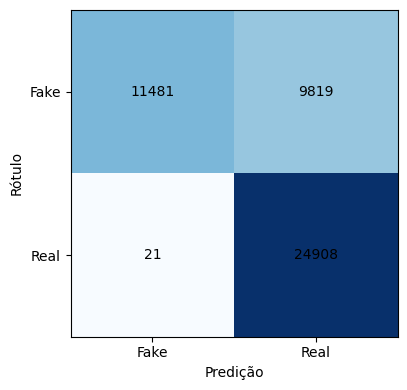

In [6]:
model_hash = sha256_file(ROOT / MODEL_RELATIVE)
external_metrics, external_audit = evaluate(external, "FakeRecogna extrativo — robustez, independência não certificada")
if sha256_file(ROOT / MODEL_RELATIVE) != model_hash:
    raise RuntimeError("O modelo foi alterado.")
external_audit.to_csv(EXTERNAL_DIR / "predicoes.csv", index=False)
external_audit.loc[~external_audit.acerto].to_csv(EXTERNAL_DIR / "erros.csv", index=False)
( EXTERNAL_DIR / "metricas.json").write_text(json.dumps({
    "tipo": "robustez_em_corpus_derivado", "independencia_confirmada": False,
    "model_sha256": model_hash, "data_sha256": sha256_file(EXTERNAL_PATH),
    "label_map": LABEL_MAP, "n_original": len(raw), "n_avaliado": len(external),
    "metrics": external_metrics}, indent=2, ensure_ascii=False), encoding="utf-8")
matriz = np.asarray(external_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(matriz, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center")
ax.set_xticks([0, 1], ["Fake", "Real"])
ax.set_yticks([0, 1], ["Fake", "Real"])
ax.set_xlabel("Predição")
ax.set_ylabel("Rótulo")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "02_confusao.png", dpi=160)
plt.show()
plt.close(fig)


## Continuação — diagnóstico e investigação

Os diagnósticos por classe e fonte, pontuações, limiar, contribuição das features, independência dos registros, comparação de modelos e auditoria OOF estão no [04_diagnostico_valicao_externa.ipynb](04_diagnostico_valicao_externa.ipynb). Execute-o após concluir esta avaliação.
